Training Test

In [ ]:
from astro_peek.utils import load_yaml
from astro_peek.trainer import training
from astro_peek.nets.architectures.cnn import CNN
cfg_dir = "../../astro_peek/configs/rings.yaml"
cfg = load_yaml(cfg_dir)
print(cfg)
encoder_features, encoder_labels, loss = training(cfg)

{'encoder_features': {'backbone': 'cnn', 'backbone_cfg': {'backbone': 'efficientnet_v2_s', 'hidden_dim': 64, 'dropout_rate': 0.1, 'output_dim': 2}, 'save_dir': '/home/noedia/links/scratch/crl/experiments/rings/models/encoder_features'}, 'encoder_labels': {'backbone': 'mlp', 'backbone_cfg': {'input_dim': 2, 'layer_widths': [8, 8, 8], 'output_dim': 2, 'activation_func': 'silu', 'activate_final': False}, 'save_dir': '/home/noedia/links/scratch/crl/experiments/rings/encoder_labels'}, 'data': {'path': '/home/noedia/links/scratch/crl/experiments/rings/data', 'data_split': None}, 'trainer': {'epochs': 50, 'optimizer': 'adam', 'batch_size': 512, 'lr': '1e-3', 'seed': 42, 'device': 'auto', 'normalize': True, 'transform': None}}
training set size:  (8000, 2)
test set size:  (2000, 2)
Running on device cpu
50


  0%|          | 0/50 [00:00<?, ?it/s]

Checking if the encoded image and encoded labels are separated in latent space or not

(array([  12.,  103.,  527., 1607., 2679., 2777., 1596.,  576.,  111.,
          12.]),
 array([0.00062029, 0.00069579, 0.00077129, 0.00084678, 0.00092228,
        0.00099778, 0.00107328, 0.00114877, 0.00122427, 0.00129977,
        0.00137527]),
 <BarContainer object of 10 artists>)

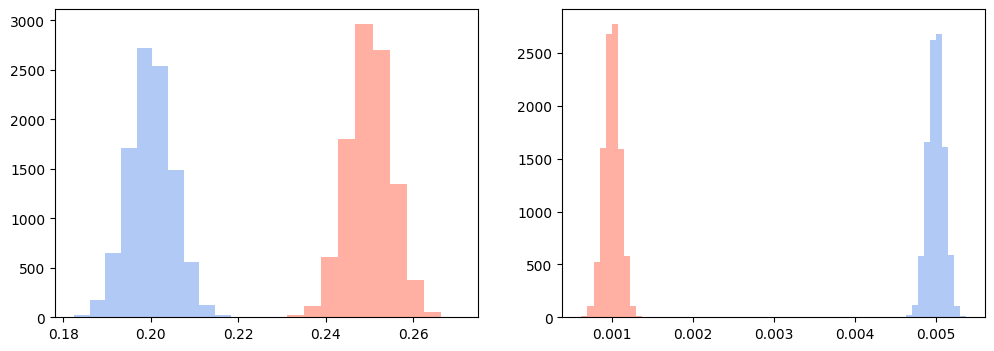

In [50]:
import numpy as np
def sample_prior(prior, size):
    return prior(size)
    
prior_radius_a = lambda size: np.random.normal(loc = 0.2, scale = 0.005, size = size)
prior_radius_b = lambda size: np.random.normal(loc = 0.25, scale = 0.005, size = size)

prior_sigma_a = lambda size: np.random.normal(loc = 5e-3, scale = 1e-4, size = size)
prior_sigma_b = lambda size: np.random.normal(loc = 1e-3, scale = 1e-4, size = size)


fig, axs = plt.subplots(1, 2, figsize = (12, 4))
ax = axs[0]
samples_a = sample_prior(prior_radius_a, size = 10_000)
samples_b = sample_prior(prior_radius_b, size = 10_000)

ax.hist(samples_a, color = "cornflowerblue", alpha  = 0.5)
ax.hist(samples_b, color = "tomato", alpha  = 0.5)


ax = axs[1]
samples_a = sample_prior(prior_sigma_a, size = 10_000)
samples_b = sample_prior(prior_sigma_b, size = 10_000)

ax.hist(samples_a, color = "cornflowerblue", alpha  = 0.5)
ax.hist(samples_b, color = "tomato", alpha  = 0.5)

In [10]:
samples_a

array([0.19307901, 0.18685041, 0.18934654, ..., 0.20189899, 0.1887922 ,
       0.20429766], shape=(10000,))

In [78]:
from datasets import load_from_disk
from tqdm import tqdm
from astro_peek.datasets.make_rings import make_rings

dataset_size = 1000

# Sampling two sets of radius and sigma to see if the model makes a difference between them in latent space.
radius_prior = {"low": 0.1, "high": 0.3}
sigma_prior = {"low": 1e-4, "high": 1e-2}
prior_params_config = {
        "radius": radius_prior, 
        "sigma": sigma_prior
    }

prior_radius_a = lambda size: np.random.normal(loc = 0.25, scale = 0.005, size = size)
prior_radius_b = lambda size: np.random.normal(loc = 0.15, scale = 0.005, size = size)

prior_sigma_a = lambda size: np.random.normal(loc = 5e-3, scale = 1e-4, size = size)
prior_sigma_b = lambda size: np.random.normal(loc = 1e-3, scale = 1e-4, size = size)

# Creating latent factors and normalizing them...
radius = np.concatenate([sample_prior(prior_radius_a, dataset_size), sample_prior(prior_radius_b, dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(radius)

sigma = np.concatenate([sample_prior(prior_sigma_a, dataset_size), sample_prior(prior_sigma_b, dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(sigma)

labels = np.concatenate([np.zeros(dataset_size), np.ones(dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(labels)

theta = np.stack([radius, sigma]).T

# Creating simulations from it 
images = []
img_size = 32
x = np.arange(0, img_size) / img_size
y = np.arange(0, img_size) / img_size
X, Y = np.meshgrid(x,y)
for params in tqdm(theta): 
    image = make_rings(X, Y, radius = params[0], sigma = params[1], center = 0.5)
    images.append(image) 

images = np.array(images)
radius = (radius - radius_prior["low"]) / (radius_prior["high"] - radius_prior["low"])
sigma =  (sigma - sigma_prior["low"]) / (sigma_prior["high"] - sigma_prior["low"])
theta = np.stack([radius, sigma]).T

100%|██████████| 2000/2000 [00:00<00:00, 84382.25it/s]


In [79]:
radius_a = np.concatenate([sample_prior(prior_radius_a, dataset_size), sample_prior(prior_radius_b, dataset_size)])
radius_b = radius_a.copy()
rng = np.random.default_rng(seed=42)
rng.shuffle(radius_a)

print(radius_a)
rng = np.random.default_rng(seed=42)
rng.shuffle(radius_b)
print(radius_b)

[0.15566631 0.25238652 0.15154666 ... 0.1552289  0.25455583 0.15629742]
[0.15566631 0.25238652 0.15154666 ... 0.1552289  0.25455583 0.15629742]


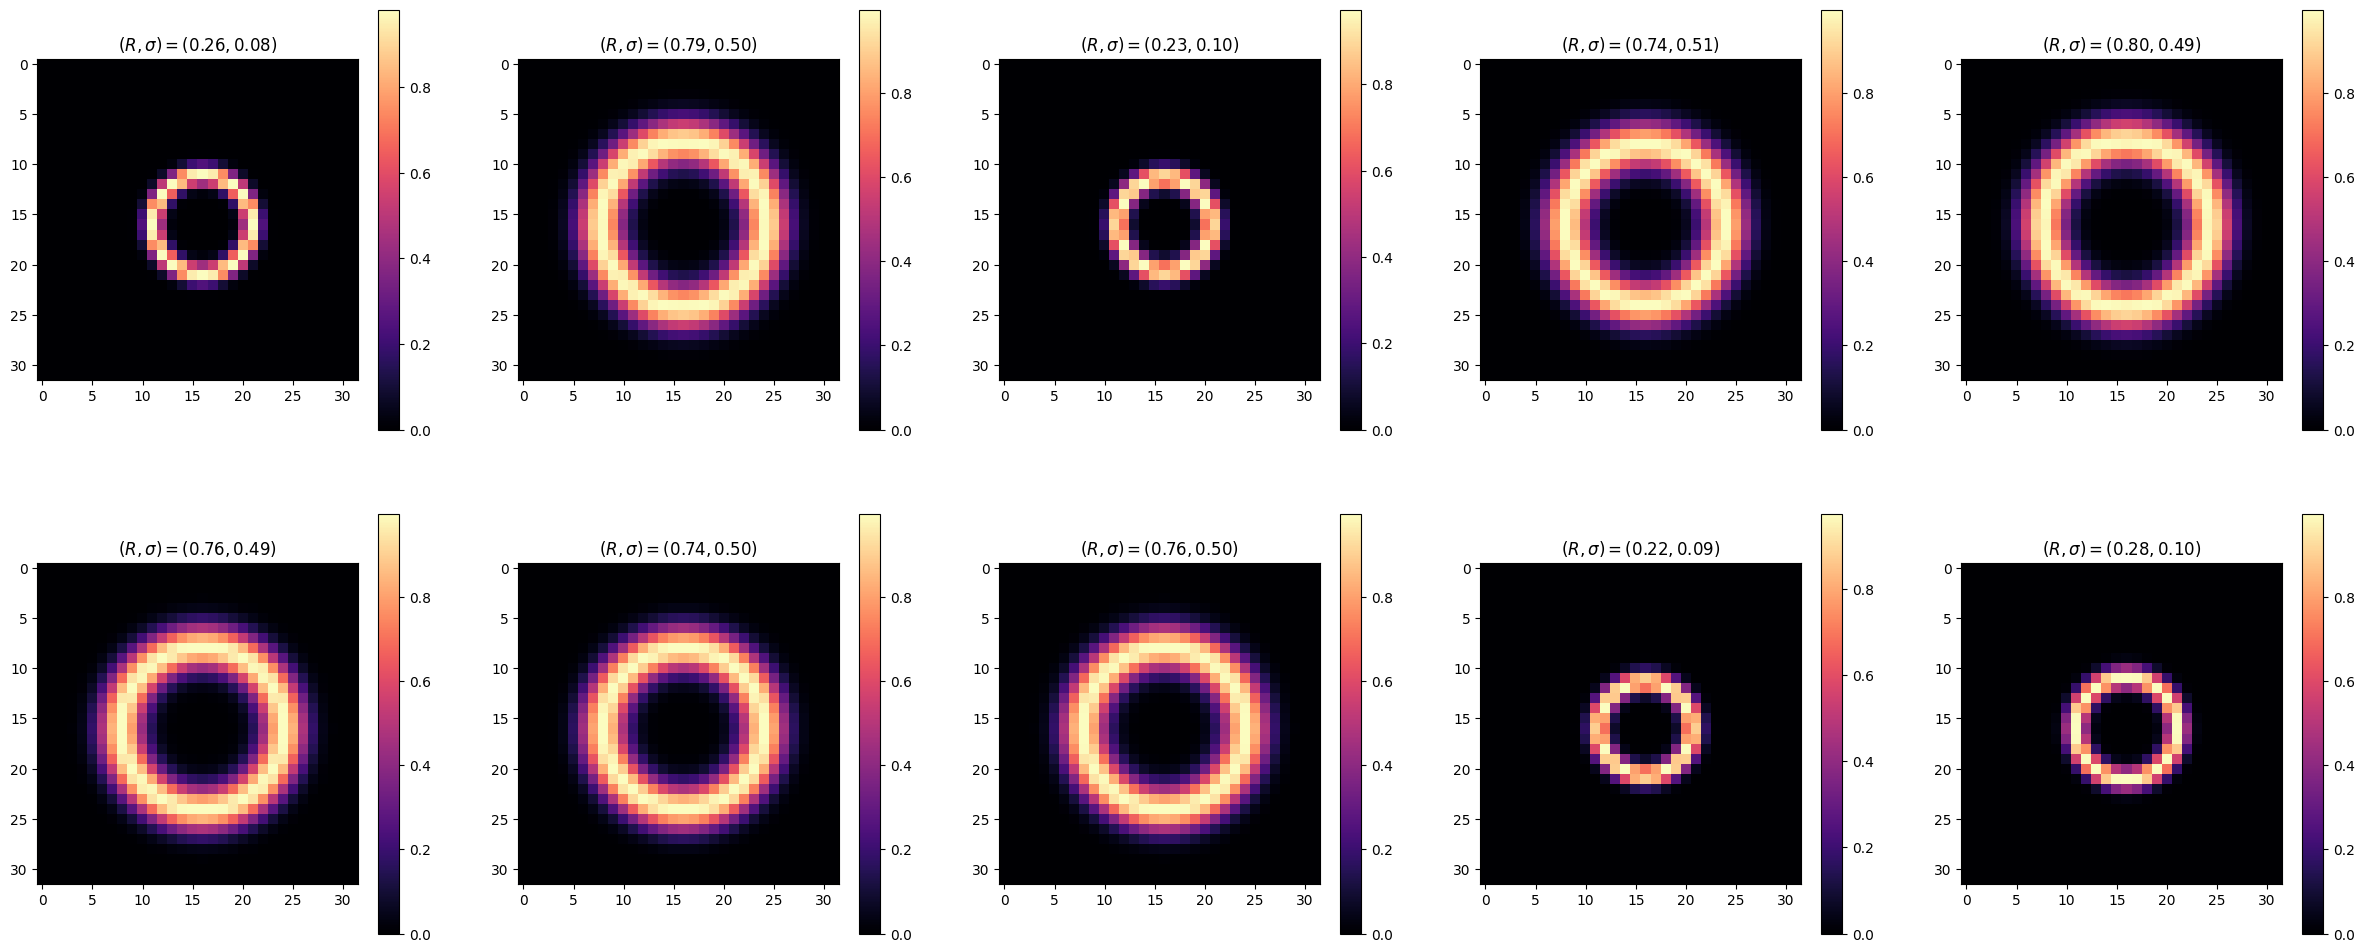

In [80]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 5, figsize = (6 * 5, 6 * 2))

for i, ax in enumerate(axs.flatten()): 
    im = ax.imshow(images[i], cmap = "magma")
    label = theta[i]
    plt.colorbar(im)
    ax.set(title = r"$(R, \sigma) = (%.2f, %.2f)$"%(label[0], label[1]))

In [81]:
import torch 
device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.tensor(images).to(device).to(torch.float32)
y = torch.tensor(theta).to(device).to(torch.float32)

with torch.no_grad():
    zx = encoder_features(x)
    zy = encoder_labels(y)

(array([846., 154.,   0.,   0.,   0.,   0.,   0.,   0.,  48., 952.]),
 array([0.05440227, 0.10153951, 0.14867675, 0.19581398, 0.24295121,
        0.29008844, 0.33722571, 0.38436294, 0.43150017, 0.4786374 ,
        0.52577466]),
 <BarContainer object of 10 artists>)

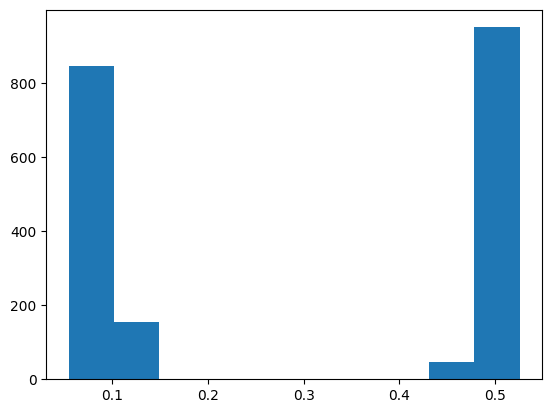

In [69]:
plt.hist(y[:, 1].cpu())

In [67]:
y.shape

torch.Size([2000, 2])

[Text(0.5, 1.0, 'Encoding features'),
 Text(0.5, 0, '$\\vec{g}(\\mathbf{y})$ 1st dim'),
 Text(0, 0.5, '$\\vec{g}(\\mathbf{y})$ 2nd dim')]

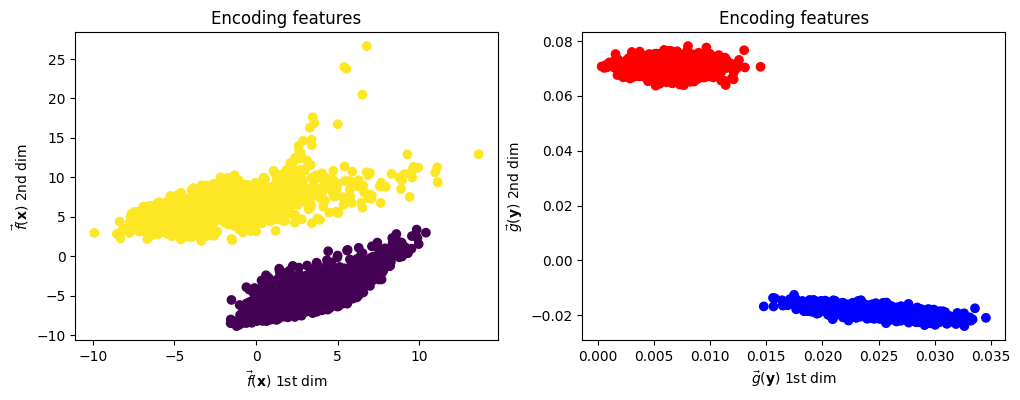

In [84]:
fig, axs = plt.subplots(1, 2, figsize = (12, 4))

ax = axs[0]
ax.scatter(*zx.cpu().T, c = labels)
ax.set(title = "Encoding features", xlabel = r"$\vec{f}(\mathbf{x})$ 1st dim", ylabel = r"$\vec{f}(\mathbf{x})$ 2nd dim")
ax = axs[1]
ax.scatter(*zy.cpu().T, c = labels, vmin  = 0, vmax = 1, cmap = "bwr")
ax.set(title = "Encoding labels", xlabel = r"$\vec{g}(\mathbf{y})$ 1st dim", ylabel = r"$\vec{g}(\mathbf{y})$ 2nd dim")

## Training 10 models with different random seeds 

## Saving model 

## Computing CCA 
From what I understand, CCA takes two matrices of size `(n_samples, n_features)` and then does some magic to compute the CCA score. 

In [ ]:
from datasets import load_from_disk
dset = load_from_disk(cfg["data"]["path"])

dset

In [3]:
float("1e-3")

0.001

In [6]:
from omegaconf import OmegaConf
hydra_cfg = OmegaConf.create(cfg)

In [8]:
hydra_cfg.encoder_features

{'backbone': 'cnn', 'backbone_cfg': {'backbone': 'efficientnet_v2_s', 'hidden_dim': 64, 'dropout_rate': 0.1, 'output_dim': 2}}